# Tutorial 1
## Aim
As I won't have time to make this package into something nice and intuitive this notebook will hopefully provide you with useful information to analyze your data, generate plots and representative images.

## Disclaimer
The project is far from being complete and essential steps for the analyses are probably still missing (eg. anisotropy of the data) and will be dealt with. Due to lack of time notebooks are for now the only way to conduct the analyses. Code is still a bit messy (as always)

- QC not implement for basal bodies yet (see analysis at the end of the notebook)


# Step 1
Setup workspace, import libraries and load data. For now, use this code inside the tutorial folder as it is not yet available as a package. 

In [1]:
import os
os.chdir("..")  # disgusting but quick fix
import limoncello as lc
import pyclesperanto_prototype as cle

Next we can select the gpu we want to use

In [2]:
print(cle.available_device_names(dev_type="gpu"))
cle.select_device('NVIDIA GeForce RTX 4090')  # optional but good practice
print(cle.get_device())

['Apple M1 Pro']
<Apple M1 Pro on Platform: Apple (2 refs)>


/Users/quillan/anaconda3/envs/interview/lib/python3.13/site-packages/pyclesperanto_prototype/_tier0/_device.py:77: UserWarning: No OpenCL device found with NVIDIA GeForce RTX 4090 in their name. Using Apple M1 Pro instead.
  warnings.warn(f"No OpenCL device found with {name} in their name. Using {device.name} instead.")


Next is the definition of the main pipeline (will be subject to change)

In [25]:
from tqdm import tqdm
from scipy.ndimage import distance_transform_edt, center_of_mass
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
def run_pipeline3(
    input_path,
    output_path,
    max_cilia_dist_cutoff_um=2.0,
    max_basal_body_cutoff_um=2.0,
    nuclei_spot_sigma=15,
    tophat_radius=12,
    neurite_spot_sigma=5,
    cilia_classifier_path=r'segmenters\cilia-segmenter.cl',
):
    os.makedirs(output_path, exist_ok=True)
    csv_dir = os.path.join(output_path, "csv")
    os.makedirs(csv_dir, exist_ok=True)

    all_dfs = []

    for file in tqdm(os.listdir(input_path)):
        if not file.endswith(".ims"):
            continue

        print(f"Processing {file}...")

        # Load data
        a, meta = lc.load_image(os.path.join(input_path, file))
        voxel_size = meta["voxel_size"]
        
        a_norm = lc.normalize_intensity(a,p_low=2,p_high=98)
        
        # Segmentation
        cilia_labels = lc.segment_cilia_ml(
            a[0, 0],
            classifier_path = cilia_classifier_path,
            )

        nuclei_labels_otsu = lc.segment_nuclei(
            a_norm[0, 3],
            tophat_radius=(tophat_radius, tophat_radius, tophat_radius),
            spot_sigma=nuclei_spot_sigma,
            outline_sigma=3,
        )

        skeleton, neurites_label = lc.segment_neurites(
            a_norm[0, 1],
            spot_sigma=neurite_spot_sigma,
        )

        basal_bodies_labels = lc.segment_basal_bodies(
            a[0,2]
        )

        # get neurites masks
        neurite_mask = np.asarray(neurites_label) > 0
        skeleton_mask = np.asarray(skeleton) > 0

        # Nuclei distance map
        distance_map_nuclei = distance_transform_edt(
            ~(nuclei_labels_otsu > 0), sampling=voxel_size
        )

        # Neurite thickness proxy (radius)
        distance_map_neurites = distance_transform_edt(
            neurite_mask, sampling=voxel_size
        )

        # Ratio
        map_ratio = np.where(distance_map_neurites > 0,
                     distance_map_nuclei / distance_map_neurites,
                     0)  # or np.nan
        map_ratio[~np.isfinite(map_ratio)] = np.nan

        # Distance to neurites 
        dist_to_neurite = distance_transform_edt(
            ~neurite_mask,
            sampling=voxel_size
        )

        # Nearest SKELETON mapping 
        _, nearest_skel_idx = distance_transform_edt(
            ~skeleton_mask,
            return_indices=True,
            sampling=voxel_size,
        )

        # Cilia centroids
        cilia_ids = np.unique(cilia_labels)
        cilia_ids = cilia_ids[cilia_ids != 0]

        cilia_centroids = center_of_mass(
            cilia_labels > 0, labels=cilia_labels, index=cilia_ids
        )

        # Basal bodies centroids
        basal_bodies_ids = np.unique(basal_bodies_labels)
        basal_bodies_ids = basal_bodies_ids[basal_bodies_ids != 0] # remove background
        basal_bodies_centroids = center_of_mass(
            basal_bodies_labels > 0, labels = basal_bodies_labels, index=basal_bodies_ids
        )


        df_cilia = lc.assign_label_features(
            cilia_labels,
            cilia_centroids,
            cilia_ids,
            dist_to_neurite,
            nearest_skel_idx,
            distance_map_neurites,
            distance_map_nuclei,
            map_ratio,
            max_cilia_dist_cutoff_um,
            file,
            )
        
        if df_cilia.empty:
            print(f"No valid cilia found in {file}")
            continue

        

        df_basal_bodies = lc.assign_label_features(
            basal_bodies_labels,
            basal_bodies_centroids,
            basal_bodies_ids,
            dist_to_neurite,
            nearest_skel_idx,
            distance_map_neurites,
            distance_map_nuclei,
            map_ratio,
            max_basal_body_cutoff_um,
            file,
            "basal_body"
        )

        #paired_df = pair_cilia_basal_bidirectional(df_cilia,df_basal_bodies)
        all_dfs.append(df_basal_bodies)
        all_dfs.append(df_cilia)

        # Overlay visualization (MIP)
        overlay_dir = os.path.join(output_path, "figures", "overlays")
        os.makedirs(overlay_dir, exist_ok=True)

        # MIP of neurite + cilia channels
        neurite_mip = np.max(a_norm[0, 1], axis=0)   # (Y, X)
        cilia_mip = np.max(a_norm[0, 0], axis=0)     # (Y, X)
        nuclei_mip = np.max(a_norm[0,3], axis = 0)
       
        fig, axes = plt.subplots(2,2, figsize=(14,10))

        # Base layer: neurites
        axes[0,0].imshow(neurite_mip, cmap="gray")
        axes[0,0].set_title('Neurites MIP')
        axes[1,1].imshow(cilia_mip,cmap='gray')
        axes[1,1].set_title('Cilia MIP')
        axes[0,1].imshow( np.log(map_ratio[map_ratio.shape[0] // 2]),cmap='coolwarm')
        axes[0,1].set_title('log(ratio) overlay')
        axes[1,0].imshow(nuclei_mip,cmap='gray')
        axes[1,0].set_title('Nuclei MIP')

        # Normalize scores for coloring (robust)
        scores = df_cilia["log_ratio"].values
        valid_scores = scores[np.isfinite(scores)]

        if len(valid_scores) > 0:
            vmin, vmax = np.percentile(valid_scores, [5, 95])
        else:
            vmin, vmax = 0, 1

        norm = plt.Normalize(vmin=vmin, vmax=vmax)
        cmap = plt.cm.coolwarm

        # Overlay cilia centroids
        coords = np.vstack(df_cilia["coords"].values)  # shape (n, 3)

        
        ys = coords[:, 1]
        xs = coords[:, 2]
        colors = cmap(norm(scores))

        axes[0,0].scatter(
            xs,
            ys,
            c=colors,
            s=10,
            edgecolor="black",
            linewidth=0.3,
            
        )
        axes[1,1].scatter(
            xs,
            ys,
            c=colors,
            s=10,
            edgecolor="black",
            linewidth=0.3,
            
        )
        axes[0,1].scatter(
            xs,
            ys,
            c=colors,
            s=10,
            edgecolor="black",
            linewidth=0.3,
            
        )
        axes[1,0].scatter(
            xs,
            ys,
            c=colors,
            s=10,
            edgecolor="black",
            linewidth=0.3,
            
        )

        # Colorbar
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        plt.colorbar(sm, ax=axes[1,0], label="log_ratio")
        plt.colorbar(sm, ax=axes[1,1], label="log_ratio")
        plt.colorbar(sm, ax=axes[0,0], label="log_ratio")
        plt.colorbar(sm, ax=axes[0,1], label="log_ratio")

        plt.axis("off")

        save_path = os.path.join(
            overlay_dir,
            f"{os.path.splitext(file)[0]}_overlay.png"
        )

        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close()

    if len(all_dfs) == 0:
        print("No data processed.")
        return

    final_df = pd.concat(all_dfs, ignore_index=True)

    # Short names
    unique_files = final_df["filename"].unique()
    file_map = {f: f"S{i+1}" for i, f in enumerate(unique_files)}
    final_df["file_short"] = final_df["filename"].map(file_map)

    
    # Classification
    def classify(score):
        if score > 2.5:
            return "axon"
        elif score < 1:
            return "soma"
        else:
            return "ambiguous"

    final_df["class"] = final_df["log_ratio"].apply(classify)

    # Figures 
    fig_dir = os.path.join(output_path, "figures")
    os.makedirs(fig_dir, exist_ok=True)

    
    # 1. Multi-panel (ratio + log-ratio)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Ratio
    final_cilia_df = final_df[final_df["object_type"] == "cilia"]
    sns.histplot(final_cilia_df["ratio"], kde=True, ax=axes[0, 0])
    axes[0, 0].set_title("Raw Ratio Distribution")

    # Log ratio
    sns.histplot(final_cilia_df["log_ratio"], kde=True, ax=axes[0, 1])
    axes[0, 1].set_title("Log Ratio Distribution")

    # Log ratio per sample (boxplot)
    sns.boxplot(data=final_cilia_df, x="file_short", y="log_ratio", ax=axes[1, 0])
    axes[1, 0].set_title("Log Ratio per Sample")
    axes[1, 0].tick_params(axis='x', rotation=45)

    # Class distribution per sample
    sns.countplot(data=final_cilia_df, x="file_short", hue="class", ax=axes[1, 1])
    axes[1, 1].set_title("Class Distribution per Sample")
    axes[1, 1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir, "overview_panels.png"), dpi=300)
    plt.close()

    # 2. KDE per sample
    plt.figure(figsize=(10, 6))

    sns.kdeplot(
        data=final_cilia_df,
        x="log_ratio",
        hue="file_short",
        common_norm=False,
    )

    plt.title("Log Ratio Distribution per Sample")
    plt.xlabel("Log Ratio")

    plt.savefig(os.path.join(fig_dir, "logratio_kde_per_sample.png"), dpi=300)
    plt.close()

    # QC + Excel
    excel_path = os.path.join(csv_dir, "all_cilia_features.xlsx")

    qc_sample = final_cilia_df.groupby("file_short").agg(
        n_cilia=("cilia_id", "count"),
        #n_basal_bodies=("basal_body_id", "count"),
        mean_ratio=("ratio", "mean"),
        std_ratio=("ratio", "std"),
        mean_log_ratio=("log_ratio", "mean"),
        std_log_ratio=("log_ratio", "std"),
        mean_distance=("distance_to_neurite_um", "mean"),
        max_distance=("distance_to_neurite_um", "max"),
    ).reset_index()

    qc_global = pd.DataFrame({
        "metric": [
            "n_total_cilia",
            "mean_ratio",
            "std_ratio",
            "mean_log_ratio",
            "std_log_ratio"
        ],
        "value": [
            len(final_cilia_df),
            final_cilia_df["ratio"].mean(),
            final_cilia_df["ratio"].std(),
            final_cilia_df["log_ratio"].mean(),
            final_cilia_df["log_ratio"].std(),
        ]
    })

    with pd.ExcelWriter(excel_path) as writer:
        final_df.to_excel(writer, sheet_name="all_data", index=False)
        qc_sample.to_excel(writer, sheet_name="qc_per_sample", index=False)
        qc_global.to_excel(writer, sheet_name="qc_global", index=False)

    print(f"Saved QC Excel: {excel_path}")


    # Scatter plot (the moment of truth)
    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        x='dt_neurite',
        y='dt_nuclei',
        hue='file_short',
        data=final_cilia_df,
        palette='tab10'
    )

    plt.xlabel("Assigned Neurite Voxel thickness (um)")
    plt.ylabel("Assigned Neurite Voxel Distance to nuclei (um)")
    plt.title("DT Comparison per Sample")
    plt.legend(bbox_to_anchor=(0.5, 1), loc='upper left')

    fig_dir = os.path.join(output_path, "figures")
    os.makedirs(fig_dir, exist_ok=True)

    plt.savefig(os.path.join(fig_dir, "dt_scatterplot.png"), dpi=300)
    plt.close()

    # Scatter plot (the moment of truth)
    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        x='log_dt_neurite',
        y='log_dt_nuclei',
        hue='file_short',
        data=final_cilia_df,
        palette='tab10'
    )

    plt.xlabel("Log of Assigned Neurite Voxel thickness (um)")
    plt.ylabel("Log of Assigned Neurite Voxel Distance to nuclei (um)")
    plt.title("Log DT Comparison per Sample")
    plt.legend(bbox_to_anchor=(0.5, 1), loc='upper left')

    fig_dir = os.path.join(output_path, "figures")
    os.makedirs(fig_dir, exist_ok=True)

    plt.savefig(os.path.join(fig_dir, "log_dt_scatterplot.png"), dpi=300)
    plt.close()


    print(f"Figures saved in: {fig_dir}")
    print("Pipeline complete.")

# 2. Run the pipeline

The pipeline takes an input path to a folder containing .ims files (and also extracts the metadata from it) it will skip other files. After processing your images, outputs will be written to the output path. Beware that if you are feeding it images from the NAS (aka server) and someone has them open this will render an error.

## Considerations
1. Cilia segmentation uses an ML pixel classifier located in ´segmenters/cilia-segmenter.cl´. Performance of the classifier depends on the data it was trained on and what you are applying it to. If it starts going crazy, retrain it, add it to the folder and update the reference path in the pipeline arguments. To retrain it use napari with the ml apoc plugin (or ask me how to).

2. The pipeline takes in a bunch of arguments for nuclei, neurite and bb segmentation. They depend on the size of the objects you want to detect (ideally you would measure objects of interest roughly in napari or fiji and update them here). The defaults should work on 40x images from the BC43

3. You will see a bunch of warnings that can be ignored when running the pipeline

4. There is a threshold for the graph that shows axon/soma/uncertain proportions (I know technically it's neurites not axon)

## Segmentation and basic analysis

In [26]:
input_path = r"C:\Users\qfavey\Documents\Thomas-test-data\Data" # r'YOURPATH'
output_path=r"tutorial\output"
cilia_classifier = r'segmenters\cilia-segmenter.cl'
run_pipeline3(input_path=input_path,output_path=output_path, cilia_classifier_path=cilia_classifier)

  0%|          | 0/3 [00:00<?, ?it/s]

Processing EXP_E6_d40_WTSII_DAPI_PCN488_TUJ1568_ARL13B647_40x_2025-08-19_(6).ims...
Opening .ims file: C:\Users\qfavey\Documents\Thomas-test-data\Data\EXP_E6_d40_WTSII_DAPI_PCN488_TUJ1568_ARL13B647_40x_2025-08-19_(6).ims
Opening readonly file: C:\Users\qfavey\Documents\Thomas-test-data\Data\EXP_E6_d40_WTSII_DAPI_PCN488_TUJ1568_ARL13B647_40x_2025-08-19_(6).ims 

Shape (T, C, Z, Y, X): (1, 4, 23, 2040, 2040)
Number of timepoints: 1
Number of channels: 4
Image dimensions (Z, Y, X): (23, 2040, 2040)
Z Resolution: 0.383
XY Resolution: (0.152, 0.152)


C:\Users\qfavey\AppData\Local\Temp\ipykernel_162496\574162758.py:73: RuntimeWarning: divide by zero encountered in divide
  distance_map_nuclei / distance_map_neurites,
C:\Users\qfavey\AppData\Local\Temp\ipykernel_162496\574162758.py:73: RuntimeWarning: invalid value encountered in divide
  distance_map_nuclei / distance_map_neurites,
c:\Users\qfavey\Documents\Code-Thomas-Test\LimonCELLo\limoncello\utils\assign_label_features.py:81: RuntimeWarning: divide by zero encountered in log
  "log_ratio": np.log(ratio),
c:\Users\qfavey\Documents\Code-Thomas-Test\LimonCELLo\limoncello\utils\assign_label_features.py:85: RuntimeWarning: divide by zero encountered in log
  "log_dt_nuclei": np.log(dt_nuclei),
C:\Users\qfavey\AppData\Local\Temp\ipykernel_162496\574162758.py:159: RuntimeWarning: divide by zero encountered in log
  axes[0,1].imshow( np.log(map_ratio[map_ratio.shape[0] // 2]),cmap='coolwarm')
 33%|███▎      | 1/3 [00:50<01:41, 50.95s/it]

Processing EXP_E6_d40_WTSII_DAPI_PCN488_TUJ1568_ARL13B647_40x_2025-08-19_(7).ims...
Opening .ims file: C:\Users\qfavey\Documents\Thomas-test-data\Data\EXP_E6_d40_WTSII_DAPI_PCN488_TUJ1568_ARL13B647_40x_2025-08-19_(7).ims
Opening readonly file: C:\Users\qfavey\Documents\Thomas-test-data\Data\EXP_E6_d40_WTSII_DAPI_PCN488_TUJ1568_ARL13B647_40x_2025-08-19_(7).ims 

Shape (T, C, Z, Y, X): (1, 4, 23, 2040, 2040)
Number of timepoints: 1
Number of channels: 4
Image dimensions (Z, Y, X): (23, 2040, 2040)
Z Resolution: 0.383
XY Resolution: (0.152, 0.152)
Closing file: C:\Users\qfavey\Documents\Thomas-test-data\Data\EXP_E6_d40_WTSII_DAPI_PCN488_TUJ1568_ARL13B647_40x_2025-08-19_(6).ims 



C:\Users\qfavey\AppData\Local\Temp\ipykernel_162496\574162758.py:73: RuntimeWarning: divide by zero encountered in divide
  distance_map_nuclei / distance_map_neurites,
C:\Users\qfavey\AppData\Local\Temp\ipykernel_162496\574162758.py:73: RuntimeWarning: invalid value encountered in divide
  distance_map_nuclei / distance_map_neurites,
c:\Users\qfavey\Documents\Code-Thomas-Test\LimonCELLo\limoncello\utils\assign_label_features.py:81: RuntimeWarning: divide by zero encountered in log
  "log_ratio": np.log(ratio),
c:\Users\qfavey\Documents\Code-Thomas-Test\LimonCELLo\limoncello\utils\assign_label_features.py:85: RuntimeWarning: divide by zero encountered in log
  "log_dt_nuclei": np.log(dt_nuclei),
C:\Users\qfavey\AppData\Local\Temp\ipykernel_162496\574162758.py:159: RuntimeWarning: divide by zero encountered in log
  axes[0,1].imshow( np.log(map_ratio[map_ratio.shape[0] // 2]),cmap='coolwarm')
 67%|██████▋   | 2/3 [01:42<00:51, 51.08s/it]

Processing EXP_E6_d40_WTSII_DAPI_PCN488_TUJ1568_ARL13B647_40x_2025-08-19_(9).ims...
Opening .ims file: C:\Users\qfavey\Documents\Thomas-test-data\Data\EXP_E6_d40_WTSII_DAPI_PCN488_TUJ1568_ARL13B647_40x_2025-08-19_(9).ims
Opening readonly file: C:\Users\qfavey\Documents\Thomas-test-data\Data\EXP_E6_d40_WTSII_DAPI_PCN488_TUJ1568_ARL13B647_40x_2025-08-19_(9).ims 

Shape (T, C, Z, Y, X): (1, 4, 23, 2040, 2040)
Number of timepoints: 1
Number of channels: 4
Image dimensions (Z, Y, X): (23, 2040, 2040)
Z Resolution: 0.383
XY Resolution: (0.152, 0.152)
Closing file: C:\Users\qfavey\Documents\Thomas-test-data\Data\EXP_E6_d40_WTSII_DAPI_PCN488_TUJ1568_ARL13B647_40x_2025-08-19_(7).ims 



C:\Users\qfavey\AppData\Local\Temp\ipykernel_162496\574162758.py:73: RuntimeWarning: divide by zero encountered in divide
  distance_map_nuclei / distance_map_neurites,
C:\Users\qfavey\AppData\Local\Temp\ipykernel_162496\574162758.py:73: RuntimeWarning: invalid value encountered in divide
  distance_map_nuclei / distance_map_neurites,
c:\Users\qfavey\Documents\Code-Thomas-Test\LimonCELLo\limoncello\utils\assign_label_features.py:81: RuntimeWarning: divide by zero encountered in log
  "log_ratio": np.log(ratio),
c:\Users\qfavey\Documents\Code-Thomas-Test\LimonCELLo\limoncello\utils\assign_label_features.py:85: RuntimeWarning: divide by zero encountered in log
  "log_dt_nuclei": np.log(dt_nuclei),
C:\Users\qfavey\AppData\Local\Temp\ipykernel_162496\574162758.py:159: RuntimeWarning: divide by zero encountered in log
  axes[0,1].imshow( np.log(map_ratio[map_ratio.shape[0] // 2]),cmap='coolwarm')
100%|██████████| 3/3 [02:34<00:00, 51.48s/it]
c:\Users\qfavey\.conda\envs\napari-env-q\lib\site

Saved QC Excel: tutorial\output\csv\all_cilia_features.xlsx
Figures saved in: tutorial\output\figures
Pipeline complete.
Closing file: C:\Users\qfavey\Documents\Thomas-test-data\Data\EXP_E6_d40_WTSII_DAPI_PCN488_TUJ1568_ARL13B647_40x_2025-08-19_(9).ims 



We can then inspect the output folder QC and overview of the results. What you will want for graphpad is in the excel file. Unfortunately badal body - cilia pairing is not yet integrated in the pipeline so we will do it manually here and generate a few graphs.

In [3]:
import pandas as pd
# read the 
df = pd.read_excel(r'tutorial\output\csv\all_cilia_features.xlsx')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'tutorial\\output\\csv\\all_cilia_features.xlsx'

In [28]:
# Get unique file_short labels
file_labels = df['file_short'].unique()

# Process each label and store the results in a list
paired_dfs = [lc.pair_from_mixed_df(df[df['file_short'] == label]) for label in file_labels]

# Concatenate all results into a single dataframe
final_df = pd.concat(paired_dfs, ignore_index=True)

# Optional: preview
final_df.head()

,filename,cilia_id,coords,distance_to_neurite_um,ratio,log_ratio,dt_neurite,dt_nuclei,log_dt_neurite,log_dt_nuclei,object_type,file_short,class,paired_id,pair_distance_um,pairing_status
0,EXP_E6_d40_WTSII_DAPI_PCN488_TUJ1568_ARL13B647...,1,"[np.float64(12.655128205128205), np.float64(43...",1.222115,6.726812,1.906101,0.304000,2.044951,-1.190728,0.715374,basal_body,S1,ambiguous,1.0,4.677405,paired
1,EXP_E6_d40_WTSII_DAPI_PCN488_TUJ1568_ARL13B647...,2,"[np.float64(10.15625), np.float64(270.7109375)...",0.000000,5.257915,1.659734,0.760000,3.996015,-0.274437,1.385298,basal_body,S1,ambiguous,3.0,4.491678,paired
2,EXP_E6_d40_WTSII_DAPI_PCN488_TUJ1568_ARL13B647...,3,"[np.float64(9.859866539561487), np.float64(520...",0.033143,9.844726,2.286936,0.429921,4.232454,-0.844154,1.442782,basal_body,S1,ambiguous,2.0,11.102538,paired
3,EXP_E6_d40_WTSII_DAPI_PCN488_TUJ1568_ARL13B647...,4,"[np.float64(13.134453781512605), np.float64(44...",0.405344,6.726812,1.906101,0.304000,2.044951,-1.190728,0.715374,basal_body,S1,ambiguous,NaN,NaN,lonely
4,EXP_E6_d40_WTSII_DAPI_PCN488_TUJ1568_ARL13B647...,5,"[np.float64(10.923404255319149), np.float64(13...",0.000000,0.174561,-1.745480,3.894135,0.679765,1.359472,-0.386009,basal_body,S1,soma,NaN,NaN,lonely


Now that we have a dataframe with basal body information available, we can start plotting. Note: use pair_distance_um not pairing_status

In [36]:
cilia_df = final_df[final_df['object_type'] == 'cilia']
bb_df = final_df[final_df['object_type'] == 'basal_body']

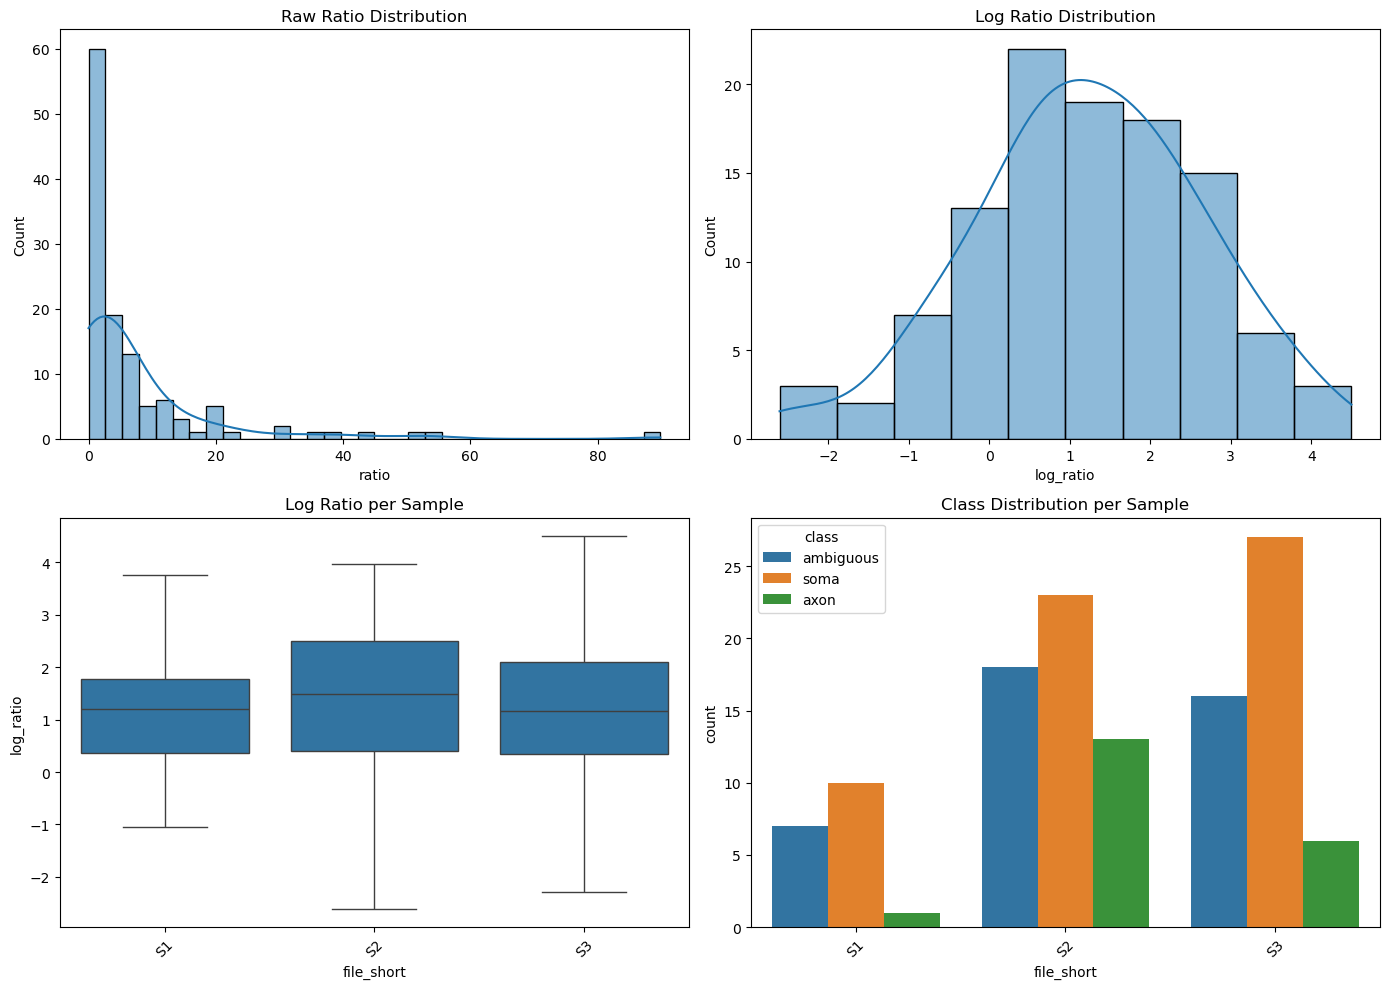

In [53]:
# 1. Multi-panel (ratio + log-ratio)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Ratio
df_to_plot = cilia_df[cilia_df['pair_distance_um']<15]
sns.histplot(df_to_plot['ratio'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Raw Ratio Distribution")

# Log ratio
sns.histplot(df_to_plot['log_ratio'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Log Ratio Distribution")

# Log ratio per sample (boxplot)
sns.boxplot(data=df_to_plot, x="file_short", y="log_ratio", ax=axes[1, 0])
axes[1, 0].set_title("Log Ratio per Sample")
axes[1, 0].tick_params(axis='x', rotation=45)

# Class distribution per sample
sns.countplot(data=df_to_plot, x="file_short", hue="class", ax=axes[1, 1])
axes[1, 1].set_title("Class Distribution per Sample")
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()

Text(0.5, 1.0, 'Basal body stats')

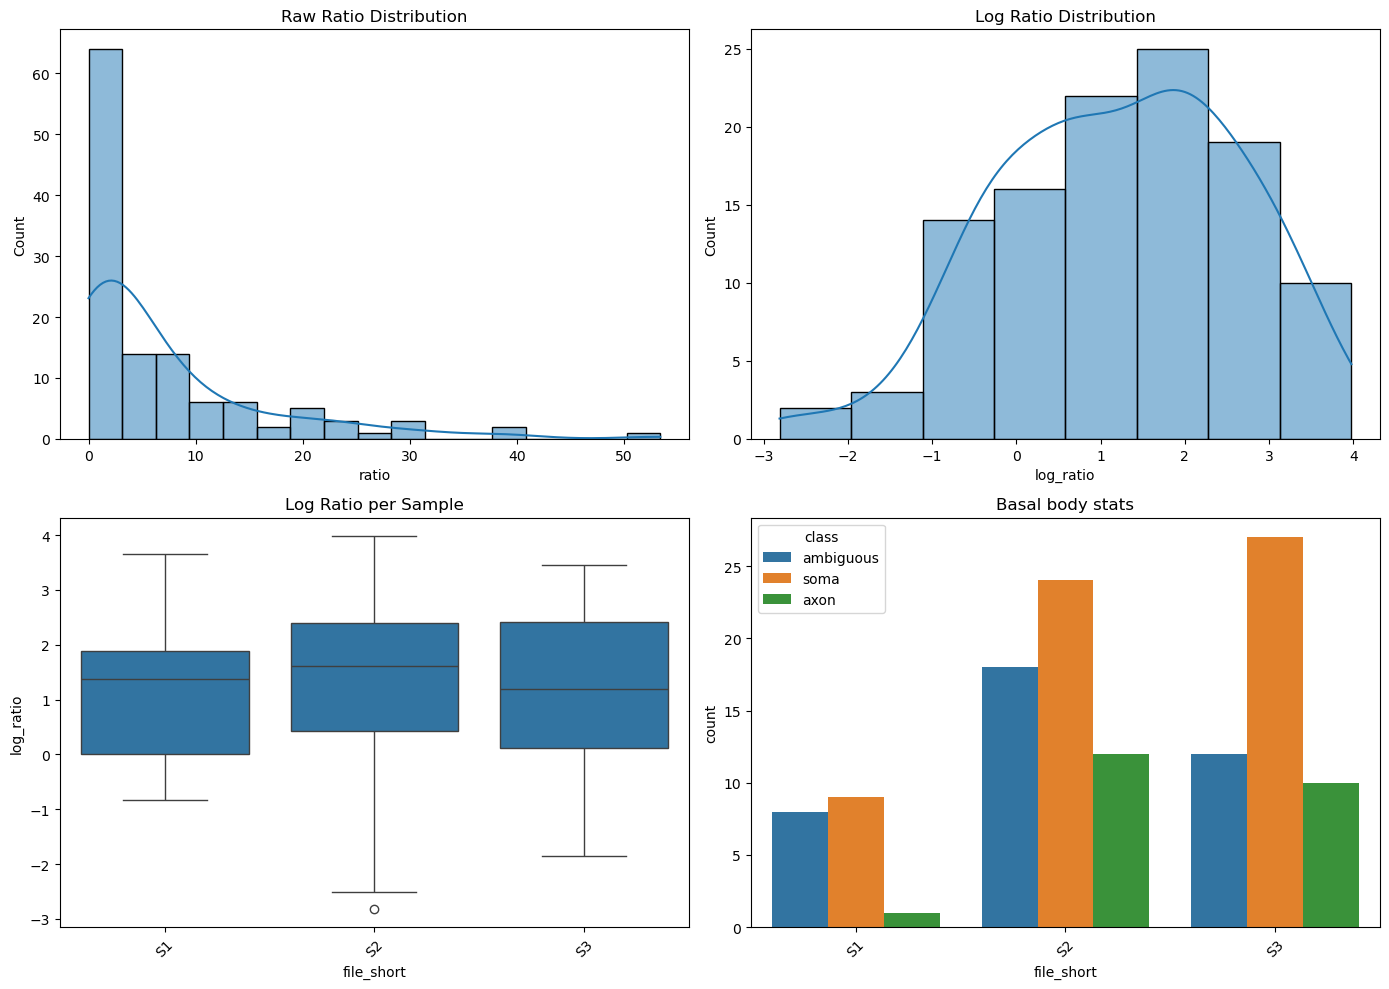

In [54]:
# 1. Multi-panel (ratio + log-ratio)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Ratio
df_to_plot = bb_df[bb_df['pair_distance_um']<15]
sns.histplot(df_to_plot['ratio'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Raw Ratio Distribution")

# Log ratio
sns.histplot(df_to_plot['log_ratio'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Log Ratio Distribution")

# Log ratio per sample (boxplot)
sns.boxplot(data=df_to_plot, x="file_short", y="log_ratio", ax=axes[1, 0])
axes[1, 0].set_title("Log Ratio per Sample")
axes[1, 0].tick_params(axis='x', rotation=45)

# Class distribution per sample
sns.countplot(data=df_to_plot, x="file_short", hue="class", ax=axes[1, 1])
axes[1, 1].set_title("Class Distribution per Sample")
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.title("Basal body stats", loc='center')

In [52]:
import pandas as pd
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display

df = final_df[final_df['pair_distance_um']<5].copy()

# Sliders
dist_slider = widgets.FloatRangeSlider(
    value=[0, df['distance_to_neurite_um'].max()],
    min=0,
    max=df['distance_to_neurite_um'].max(),
    step=0.1,
    description='Distance:'
)

ratio_slider = widgets.FloatRangeSlider(
    value=[df['log_ratio'].min(), df['log_ratio'].max()],
    min=df['log_ratio'].min(),
    max=df['log_ratio'].max(),
    step=0.1,
    description='Log ratio:'
)

def update_plot(dist_range, ratio_range):
    dff = df[
        (df['distance_to_neurite_um'].between(*dist_range)) &
        (df['log_ratio'].between(*ratio_range))
    ]

    fig = px.scatter(
        dff,
        x="distance_to_neurite_um",
        y="log_ratio",
        color="object_type",
        facet_col="file_short",
        hover_data=["filename", "cilia_id", "pairing_status"]
    )
    fig.show()

widgets.interact(update_plot,
                 dist_range=dist_slider,
                 ratio_range=ratio_slider)

c:\Users\qfavey\.conda\envs\napari-env-q\lib\site-packages\jupyter_client\session.py:727: UserWarning: Message serialization failed with:
Out of range float values are not JSON compliant
Supporting this message is deprecated in jupyter-client 7, please make sure your message is JSON-compliant
  content = self.pack(content)


interactive(children=(FloatRangeSlider(value=(0.0, 1.94036150133048), description='Distance:', max=1.940361501…

<function __main__.update_plot(dist_range, ratio_range)>

In [23]:
import plotly.graph_objects as go

variables = [
    'distance_to_neurite_um', 'ratio', 'log_ratio',
    'dt_neurite', 'dt_nuclei',
    'log_dt_neurite', 'log_dt_nuclei',
    'pair_distance_um'
]

x_var = 'distance_to_neurite_um'
y_var = 'ratio'

fig = go.Figure()

for obj in final_df['object_type'].unique():
    sub = final_df[final_df['object_type'] == obj]
    fig.add_trace(go.Scatter(
        x=sub[x_var],
        y=sub[y_var],
        mode='markers',
        name=obj,
        visible=True
    ))

# Dropdown for x-axis
dropdown_x = [
    dict(
        label=var,
        method="update",
        args=[{"x": [final_df[var] for _ in final_df['object_type'].unique()]},
              {"xaxis": {"title": var}}]
    )
    for var in variables
]

# Dropdown for y-axis
dropdown_y = [
    dict(
        label=var,
        method="update",
        args=[{"y": [final_df[var] for _ in final_df['object_type'].unique()]},
              {"yaxis": {"title": var}}]
    )
    for var in variables
]

fig.update_layout(
    updatemenus=[
        dict(buttons=dropdown_x, direction="down", x=0.1, y=1.15),
        dict(buttons=dropdown_y, direction="down", x=0.3, y=1.15),
    ]
)

fig.update_layout(title="Interactive scatter", height=600)
fig.show()